# Dubawnt Group ca. 1796 Ma paleomagnetic pole

## Geologic context

The Dubawnt Group (Baker Lake Basin, western Churchill Province, Nunavut) is a
Late Paleoproterozoic red-bed and volcanic succession of the Baker Lake Group,
the lowermost sequence of the Dubawnt Supergroup. Park, Irving & Donaldson (1973)
sampled three units: the **Kazan Formation** (cross-bedded red arkose, siltstone
and mudstone; 20 sites), the **Christopher Island Formation** (trachyte-andesite
lava flows, dikes, a lapilli tuff and interbedded red sandstone; 9 sites) and the
**Martell Syenite** (the intrusive equivalent of the Christopher Island volcanics;
1 site). The characteristic remanence of the red beds is carried by specular and
disseminated hematite and was isolated by thermal demagnetization (500-600 C),
while the volcanic rocks carry a two-component remanence (unstable titanomagnetite
plus a stable specular-hematite/magnetite component) isolated by alternating-field
demagnetization. Principal-component analysis was not used (1973).

## Age constraints

Park et al. (1973) originally assigned the pole ~1725 Ma from K-Ar (biotite/
phlogopite, ~1716 Ma) and a Rb-Sr isochron (1725 +/- 4 Ma) computed with old
decay constants; these are superseded. Modern U-Pb and Ar-Ar geochronology brackets
the sampled units:

- **1833 +/- 3 Ma** (U-Pb zircon, 2 sigma; Rainbird et al., 2006) on a basal
  Christopher Island Formation felsic minette flow -- the oldest sampled unit and
  the **maximum** age of the pole (corroborated by an Ar-Ar phlogopite age of
  1837 +/- 8 Ma and a Kazan-Formation xenotime diagenetic age of 1838 +/- 27 Ma).
- **1811 +/- 12 Ma** (Ar-Ar phlogopite; Rainbird et al., 2006) on a syenite plug
  that cross-cuts the alluvial sandstones of the Kazan Formation and the
  intercalated volcanic and pyroclastic rocks of the Christopher Island Formation
  -- i.e. the sedimentary and volcanic units sampled here -- providing a
  **minimum** age for the sampled units. (This is a later intrusion, distinct from
  Park et al.'s comagmatic Martell Syenite.)
- **1757.6 +/- 3.4 Ma** (U-Pb zircon; Rainbird & Davis, 2007) on Pitz Formation
  rhyolite of the overlying Wharton Group, which unconformably overlies the
  sampled Baker Lake Group and sets a conservative **younger** bound.

The nominal age adopted here is **1796 Ma**, the midpoint of the conservative
1758-1833 Ma U-Pb-to-U-Pb bracket. Because the cross-cutting 1811 Ma syenite
post-dates the sampled units, the pole most likely lies in the older half of the
bracket.

## Site-level MagIC contribution

There is no pre-existing MagIC contribution for Park et al. (1973), so the
site-level directions were compiled from Table 1 of the paper into a new MagIC
contribution documented in `../data/1796_Dubawnt/contribution_build/`
(`Park1973_Dubawnt_Table1.csv` and `build_dubawnt.py`), which writes `sites.txt`,
`locations.txt` and `ages.txt` and validates the combined upload. Park et al.
(1973) did not tabulate per-site alpha95/k or per-site coordinates; all sites
therefore carry the single mean sampling location (64.1 N / 94.7 W = 265.3 E) and
no site-level precision, and per-site VGPs are computed from the cleaned,
bedding-corrected directions with `pmag.dia_vgp`.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

The directions are bedding-corrected (`dir_tilt_correction = 100`), so
`pt.load_magic_sites` returns them in the tilt-corrected frame. The excluded
lapilli-tuff site (23, randomly magnetized) is flagged `result_quality='b'` and
dropped, leaving the 30 sites of Park et al.'s (1973) mean.

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1796_Dubawnt/sites.txt')
sites_pole = sites_tc if len(sites_tc) else sites_geo
study_lat, study_lon = 64.1, 265.3
print(f'{len(sites_pole)} sites in the pole '
      f"({(sites_pole['geologic_classes'] == 'Sedimentary').sum()} sedimentary, "
      f"{(sites_pole['geologic_classes'].isin(['Extrusive', 'Intrusive'])).sum()} igneous)")
sites_pole[['site', 'description', 'geologic_classes', 'lithologies', 'dir_dec',
            'dir_inc', 'dir_n_samples', 'dir_polarity', 'vgp_lat', 'vgp_lon']]

30 sites in the pole (22 sedimentary, 8 igneous)


,site,description,geologic_classes,lithologies,dir_dec,dir_inc,dir_n_samples,dir_polarity,vgp_lat,vgp_lon
0,28,Martell Syenite: syenite,Intrusive,Syenite,338,-51,4,r,-7.4,104.0
1,1,Christopher Island Formation: lava,Extrusive,Trachyte,56,-40,4,r,-7.1,34.9
2,27,Christopher Island Formation: red sandstone,Sedimentary,Sandstone,302,-59,2,r,-23.4,130.6
3,26,Christopher Island Formation: lava,Extrusive,Trachyte,283,-46,5,r,-19.0,151.6
4,10,Christopher Island Formation: lava,Extrusive,Trachyte,355,-56,5,r,-10.7,89.4
5,11,Christopher Island Formation: lava,Extrusive,Trachyte,352,-60,5,r,-15.2,91.6
6,32,Christopher Island Formation: red sandstone,Sedimentary,Sandstone,1,-78,2,r,-41.1,84.8
7,30,Christopher Island Formation: dike,Intrusive,Basalt,198,48,6,n,4.2,249.6
8,2,Christopher Island Formation: dike and baked host,Intrusive,Basalt,327,-55,16,r,-13.0,112.4
9,9,Christopher Island Formation: dike and baked host,Intrusive,Basalt,353,-69,8,NaN,-26.7,90.1


## Mean pole from VGPs

The Fisher mean of the 30 bedding-corrected site VGPs reproduces the pole
published by Park et al. (1973).

Plon: 276.5  Plat: 7.7
Number of directions in mean (n): 30
Angular radius of 95% confidence (A_95): 7.9
Precision parameter (k) estimate: 12.0

Park et al. (1973) published pole: 7 N / 277 E (083 W), K 12, A95 8, N 30


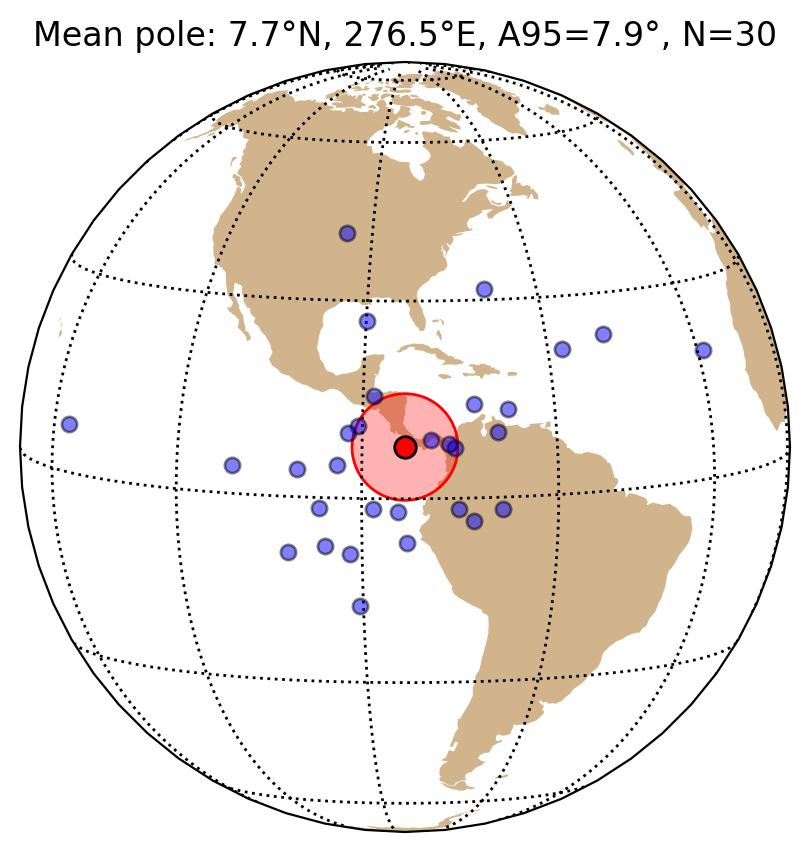

In [3]:
vgp_block, pole_mean = pt.compute_mean_pole(sites_pole, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
print('\nPark et al. (1973) published pole: 7 N / 277 E (083 W), K 12, A95 8, N 30')
pole_plot = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                                  central_latitude=pole_mean['inc'], figsize=(5, 5))
plt.show()

## Site mean direction

Directions are unified to a single polarity and averaged; the reversed-sense mean
(D ~ 347, I ~ -50) matches Park et al. (1973).

Dec: 167.6  Inc: 50.7
Number of directions in mean (n): 30
Angular radius of 95% confidence (a_95): 6.7
Precision parameter (k) estimate: 16.5


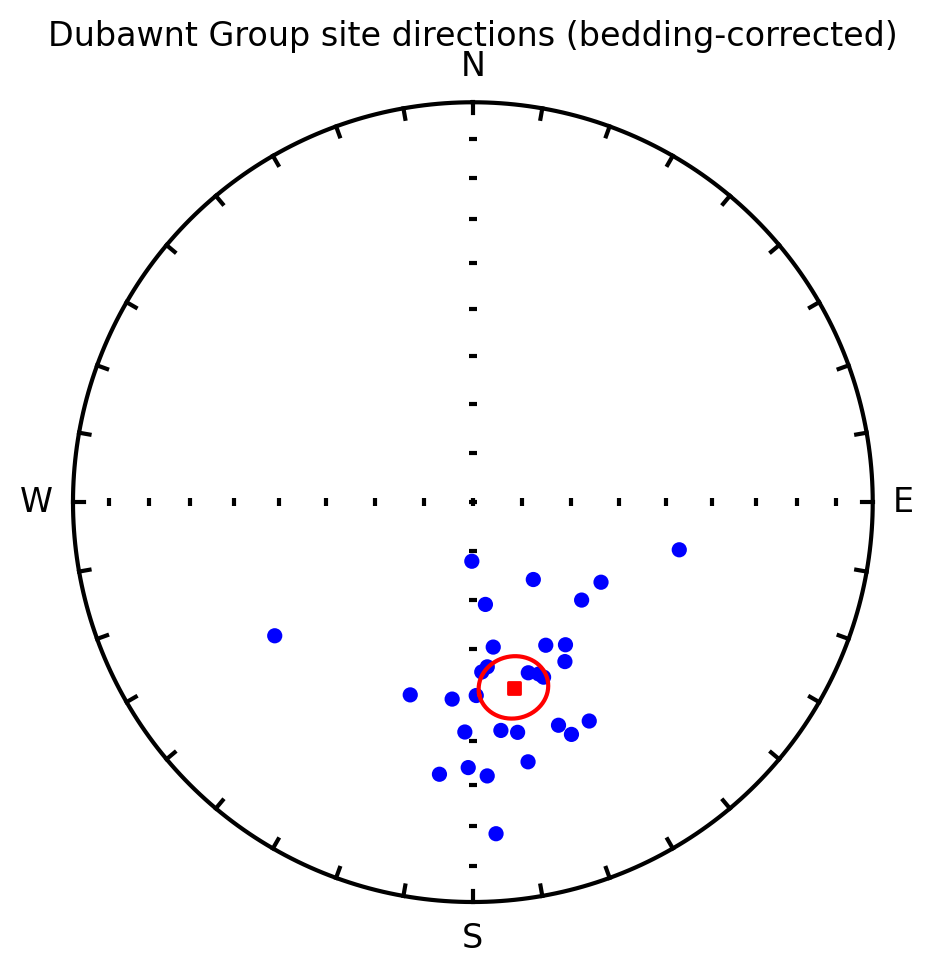

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sites_pole, unify_polarity=True)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net(label_directions=True)
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'], color='red', marker='s')
ipmag.plt.title('Dubawnt Group site directions (bedding-corrected)')
ipmag.plt.show()

## Common-mean test: sedimentary vs. volcanic rocks

The Dubawnt pole combines red-bed (sedimentary) and lava/dike/syenite (volcanic
and intrusive) sites, whose remanences are carried by different minerals
(hematite vs. specular hematite + magnetite) and were isolated by different
methods (thermal vs. alternating-field). To justify combining them into a single
pole, we test whether the two rock-type groups share a common mean direction,
using both a non-parametric bootstrap common-mean test (Tauxe, 2010) and the
parametric Watson V test (McFadden & McElhinny, 1990). Park et al. (1973) noted
that the igneous mean inclination is ~12 deg steeper than the sedimentary mean
but that the difference is not statistically significant.

22 sedimentary sites (Kazan + Christopher Island red beds), 8 igneous sites (lavas, dikes, Martell Syenite)

sedimentary mean direction:
Dec: 166.6  Inc: 47.7
Number of directions in mean (n): 22
Angular radius of 95% confidence (a_95): 6.9
Precision parameter (k) estimate: 21.3
volcanic/igneous mean direction:
Dec: 171.6  Inc: 59.5
Number of directions in mean (n): 8
Angular radius of 95% confidence (a_95): 17.7
Precision parameter (k) estimate: 10.8


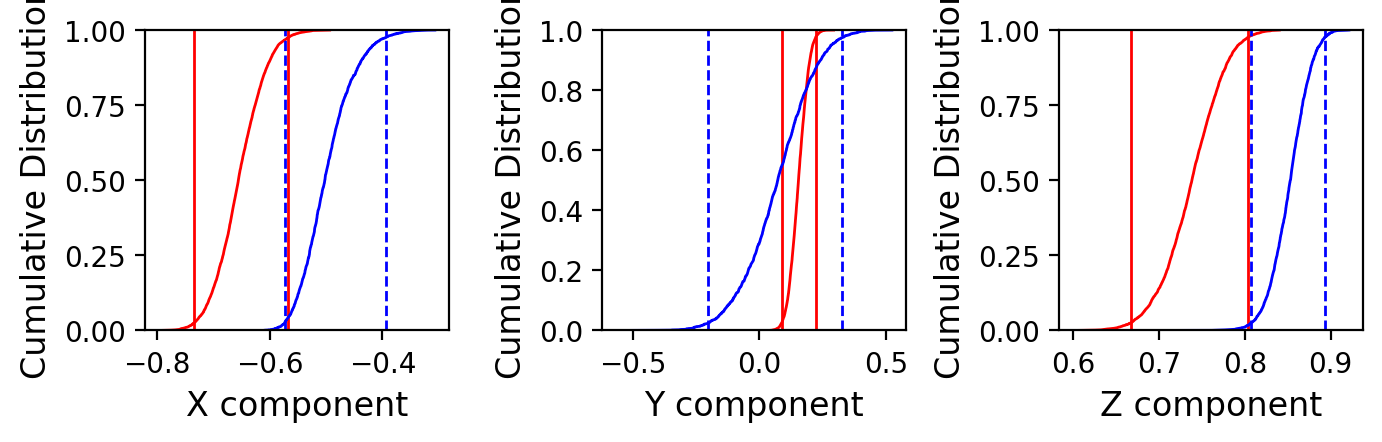

Fail, distinct in z


In [5]:
sedimentary = sites_pole[sites_pole['geologic_classes'] == 'Sedimentary'].reset_index(drop=True)
volcanic = sites_pole[sites_pole['geologic_classes'].isin(['Extrusive', 'Intrusive'])].reset_index(drop=True)
print(f'{len(sedimentary)} sedimentary sites (Kazan + Christopher Island red beds), '
      f'{len(volcanic)} igneous sites (lavas, dikes, Martell Syenite)')

_, sed_mean = pt.compute_mean_direction(sedimentary, unify_polarity=True)
_, volc_mean = pt.compute_mean_direction(volcanic, unify_polarity=True)
print('\nsedimentary mean direction:')
ipmag.print_direction_mean(sed_mean)
print('volcanic/igneous mean direction:')
ipmag.print_direction_mean(volc_mean)

# bootstrap common-mean test on the polarity-unified directions of the two groups
sed_di = pmag.flip(ipmag.make_di_block(sedimentary['dir_dec'].tolist(),
                                       sedimentary['dir_inc'].tolist()), combine=True)
volc_di = pmag.flip(ipmag.make_di_block(volcanic['dir_dec'].tolist(),
                                        volcanic['dir_inc'].tolist()), combine=True)
ipmag.common_mean_bootstrap(sed_di, volc_di)
plt.show()

### McFadden & McElhinny (1990) common-mean test

The parametric Watson V test compares the two group means against a Monte Carlo
null distribution of a common mean; V below the critical value indicates the two
directions share a common mean (a fixed random seed is set for reproducibility).

Results of Watson V test: 

Watson's V:           3.0
Critical value of V:  7.3
"Pass": Since V is less than Vcrit, the null hypothesis
that the two populations are drawn from distributions
that share a common mean direction can not be rejected.

M&M1990 classification:

Angle between data set means: 12.2
Critical angle for M&M1990:   18.9
The McFadden and McElhinny (1990) classification for
this test is: 'C'


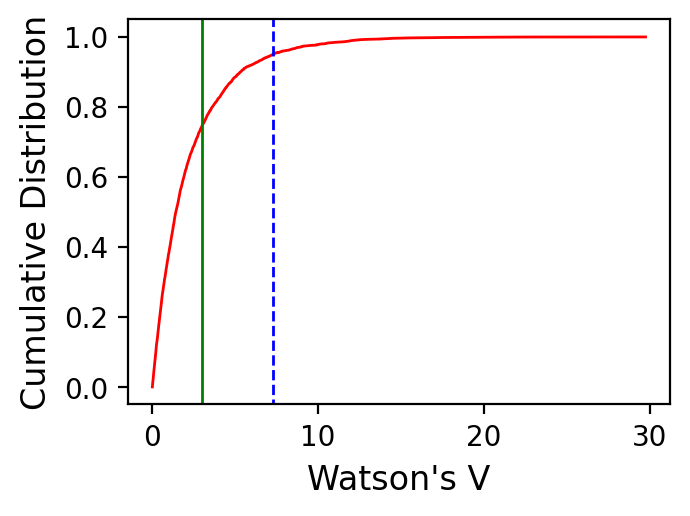

In [6]:
watson_result = ipmag.common_mean_watson(sed_di, volc_di, plot=True, random_seed=23)
plt.show()

### Site directions by rock type (unified polarity, with lithology means)

With the site directions brought to a common polarity, the sedimentary (red bed) and volcanic/intrusive groups are plotted in distinct colors on the equal-area net, together with the Fisher mean direction of each lithology group and its 95% confidence circle. The two group means overlap within their confidence circles, consistent with the common-mean test above (the volcanic mean is ~12 deg steeper, as noted by Park et al., 1973, but not significantly different).

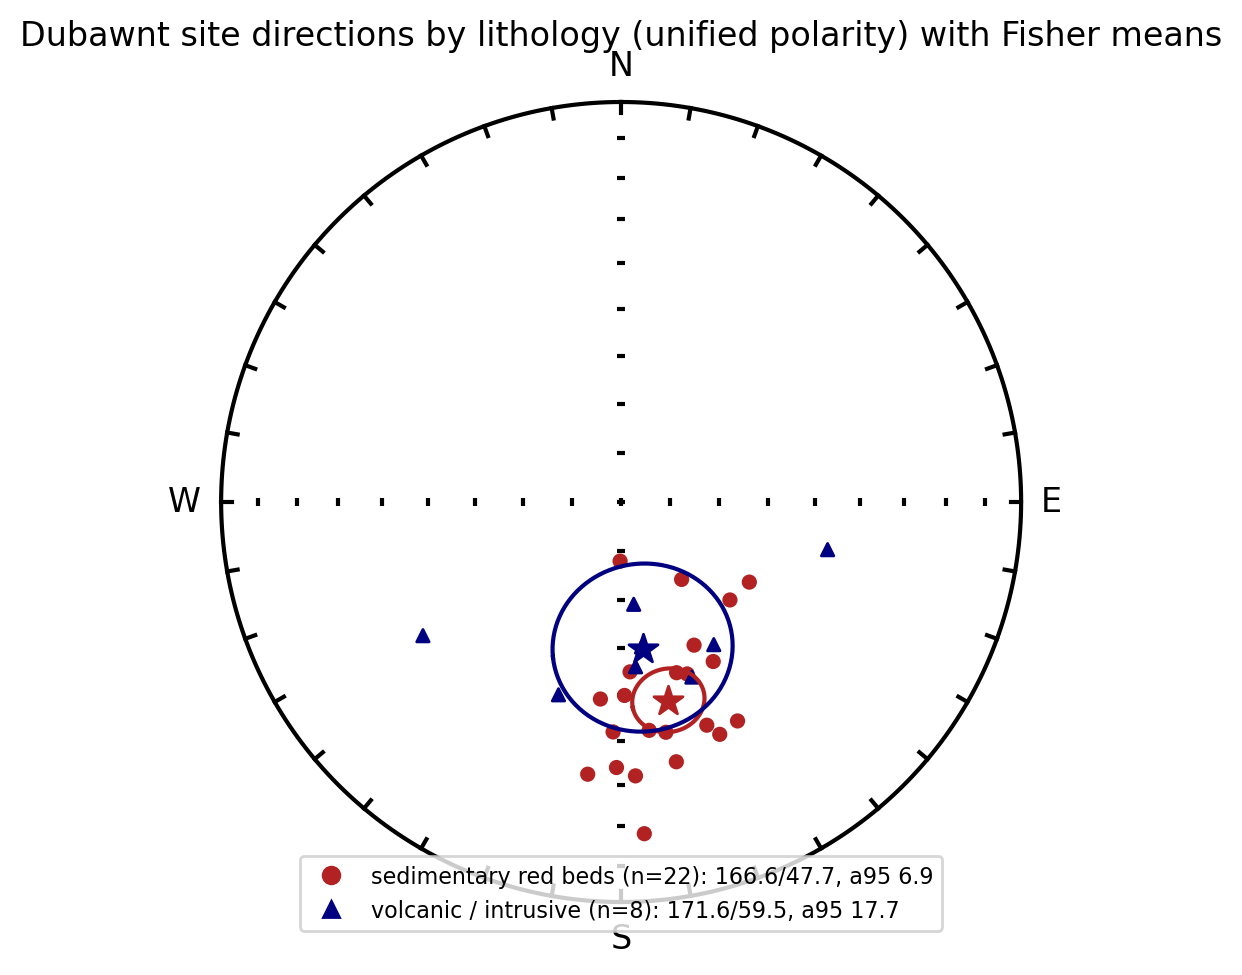

In [7]:
import matplotlib.lines as mlines

ipmag.plot_net(label_directions=True)
# polarity-unified site directions, colored by lithology group
ipmag.plot_di(di_block=sed_di, color='firebrick', marker='o')
ipmag.plot_di(di_block=volc_di, color='navy', marker='^')
# Fisher mean of each lithology group, with its alpha95 confidence circle
ipmag.plot_di_mean(sed_mean['dec'], sed_mean['inc'], sed_mean['alpha95'],
                   color='firebrick', marker='*', markersize=120)
ipmag.plot_di_mean(volc_mean['dec'], volc_mean['inc'], volc_mean['alpha95'],
                   color='navy', marker='*', markersize=120)
_sed = mlines.Line2D([], [], color='firebrick', marker='o', linestyle='None',
                     label=f"sedimentary red beds (n={len(sedimentary)}): "
                           f"{sed_mean['dec']:.1f}/{sed_mean['inc']:.1f}, a95 {sed_mean['alpha95']:.1f}")
_volc = mlines.Line2D([], [], color='navy', marker='^', linestyle='None',
                      label=f"volcanic / intrusive (n={len(volcanic)}): "
                            f"{volc_mean['dec']:.1f}/{volc_mean['inc']:.1f}, a95 {volc_mean['alpha95']:.1f}")
plt.legend(handles=[_sed, _volc], loc='lower center', fontsize=8)
plt.title('Dubawnt site directions by lithology (unified polarity) with Fisher means')
plt.show()

### Interpretation

The two lithology groups share a common mean by the parametric McFadden & McElhinny (1990) Watson V test (V = 3.0, well below the critical value; the 12.2 deg angle between the means is below the 18.7 deg critical angle, an M&M1990 classification of 'C') and by the overlap of their alpha95 confidence circles (means 12.2 deg apart, sum of alpha95 = 24.6 deg).

The non-parametric bootstrap test, however, marginally fails: the bootstrapped confidence bounds of the two means overlap in the horizontal (x, y) components but just miss in the vertical (z) component. This reflects the systematically steeper inclination of the small volcanic/intrusive group (I ~ 60 deg, n = 8) relative to the red beds (I ~ 48 deg, n = 22) -- the ~12 deg difference Park et al. (1973) noted -- while the declinations agree closely. The most likely cause is modest inclination shallowing of the detrital / early-diagenetic remanence in the Kazan red beds, a common effect in clastic sedimentary rocks, rather than a genuine difference in the recorded field direction; the component-wise bootstrap resolves this small offset in the tightly-constrained z component even though the overall confidence regions overlap.

Because the declinations agree, the parametric test and the alpha95 circles indicate a common mean, and the magnetization is supported as primary by the positive baked-contact and reversal tests, the sedimentary and volcanic sites are combined into a single Dubawnt Group pole; the modest inclination difference is averaged in the 30-site mean.

## The Dubawnt pole in the context of the Laurentia APWP

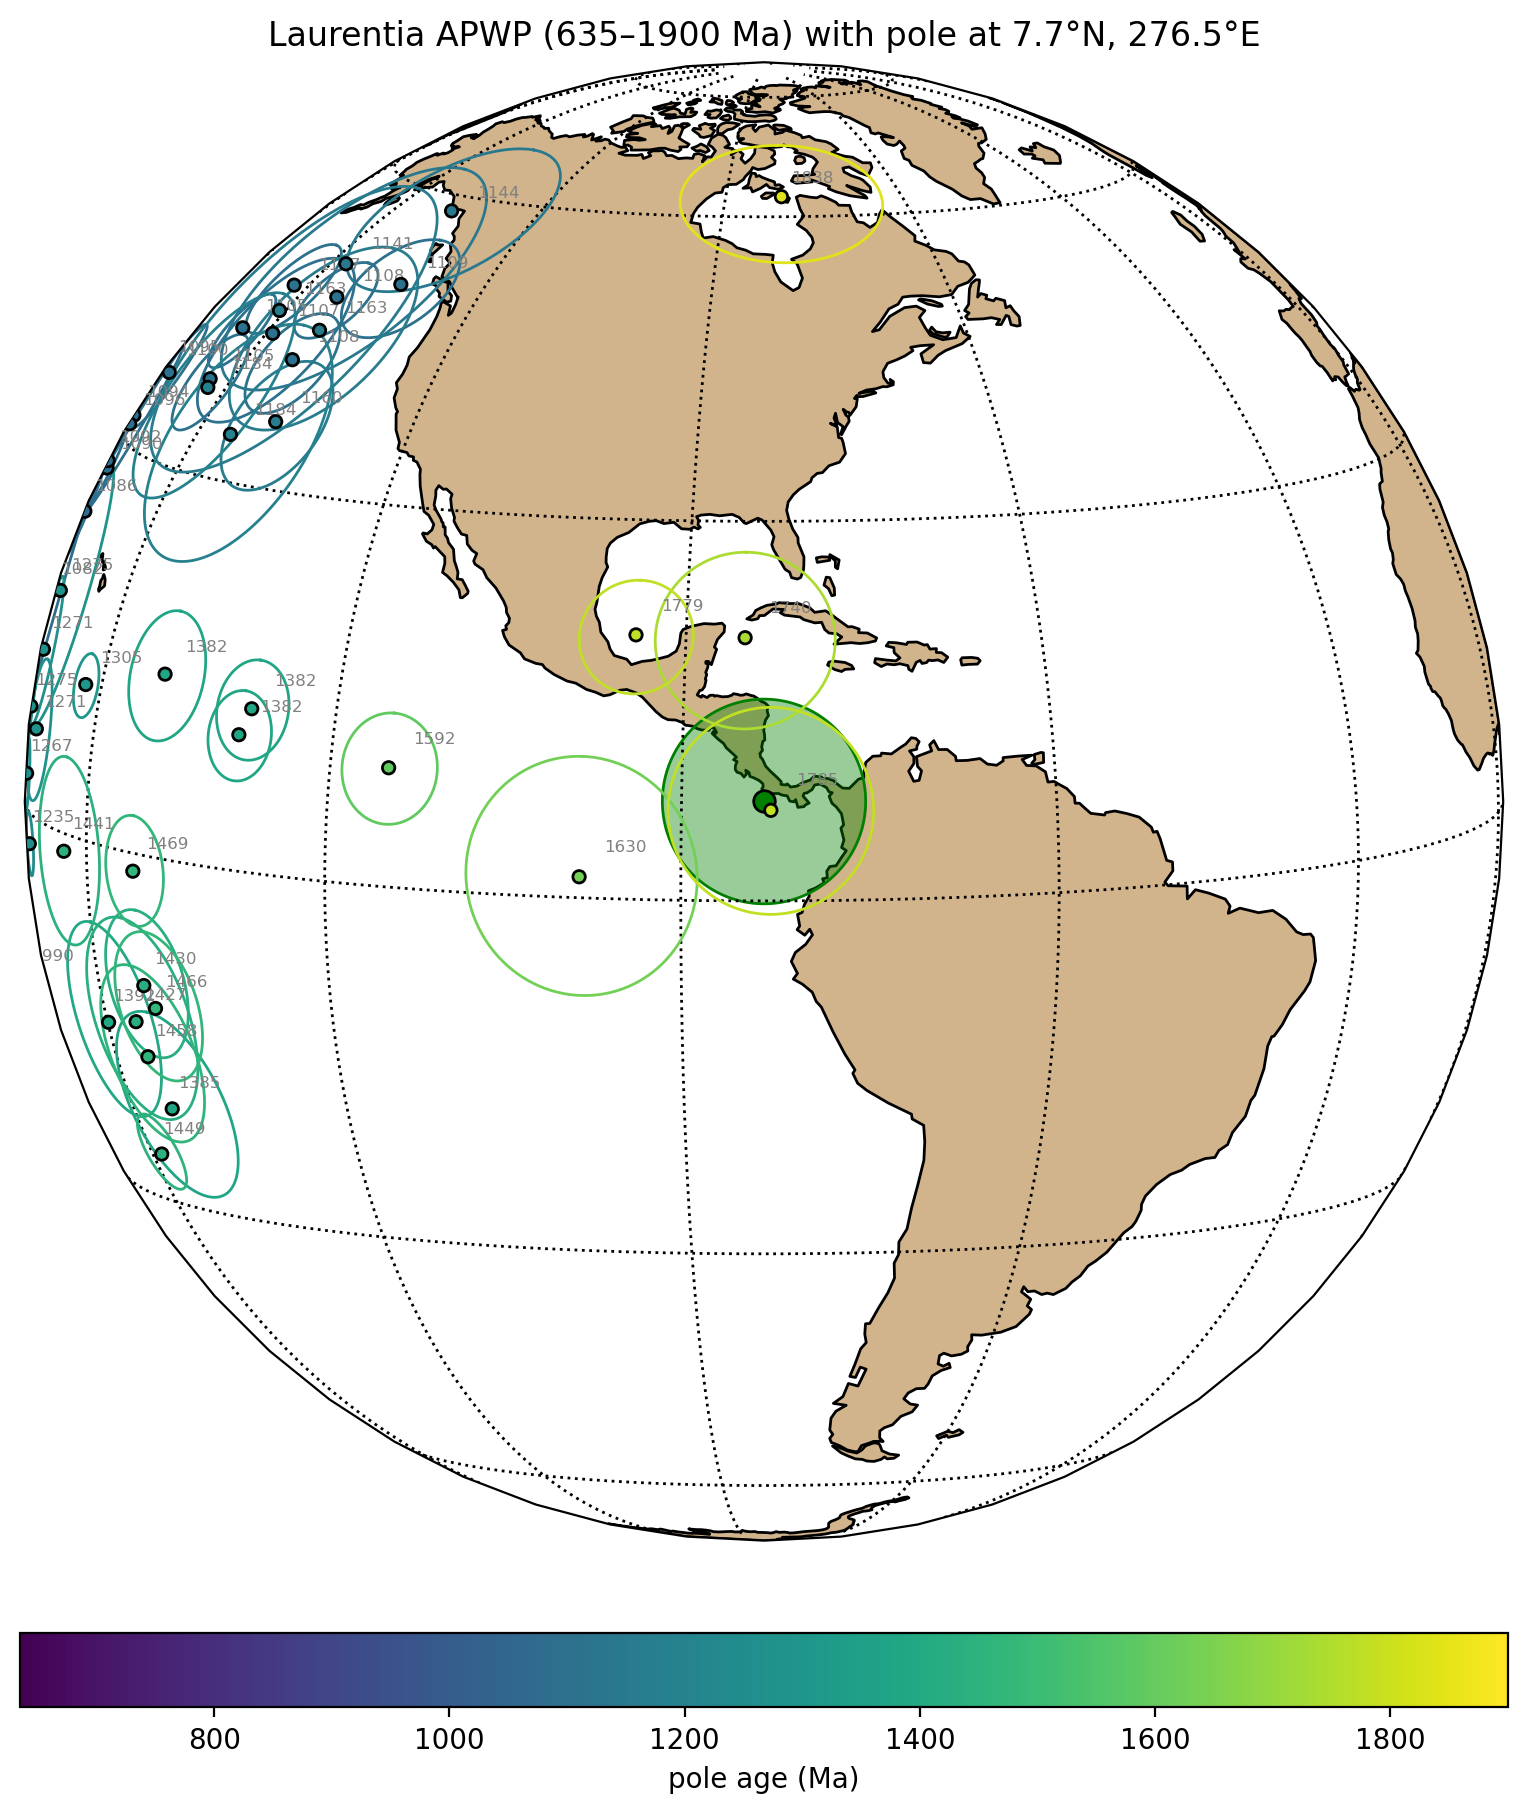

In [8]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                                       pole_mean['alpha95'], age_min=635, age_max=1900,
                                       projection='orthographic', central_longitude=pole_mean['dec'],
                                       central_latitude=pole_mean['inc'])
plt.show()

## Comparison with the ca. 1755 Ma Dubawnt rhyolite pole (Raub et al., in prep.)

A companion paper (Raub et al., in preparation for the same CJES volume) reports a paleomagnetic pole for Dubawnt rhyolites at ca. 1755 Ma. The pole is the mean of six igneous-site VGPs (47 samples): 9.1 N, 277.0 E, A95 = 11.4 (site location 63.6 N, 98.5 W). The characteristic remanence is carried by hematite in the rhyolites (characterized by thermosusceptibility and detailed thermal demagnetization); the collection records two polarities including a reversal captured across a conglomerate with a positive conglomerate test; and U-Pb ages of 1753.6 +/- 1.2, 1756 +/- 1 and 1758 +/- 3 Ma give a nominal age of ~1755 Ma. Raub et al. assign R = 1,0,1,1,1,1,1 (6/7).

At ca. 1755 Ma these rhyolites fall near the young end of Dubawnt Supergroup magmatism -- the same age as the youngest (Wharton Group) Dubawnt Supergroup rhyolites, which provide the younger bound on the Park et al. (1973) Dubawnt pole above. The Raub et al. pole lies only ~1.5 deg from the Dubawnt Group pole recalculated here (both near 8 N / 277 E), well within their mutual confidence limits, indicating limited apparent polar wander for Laurentia between the ca. 1833 Ma Christopher Island volcanism and these ca. 1755 Ma rhyolites.

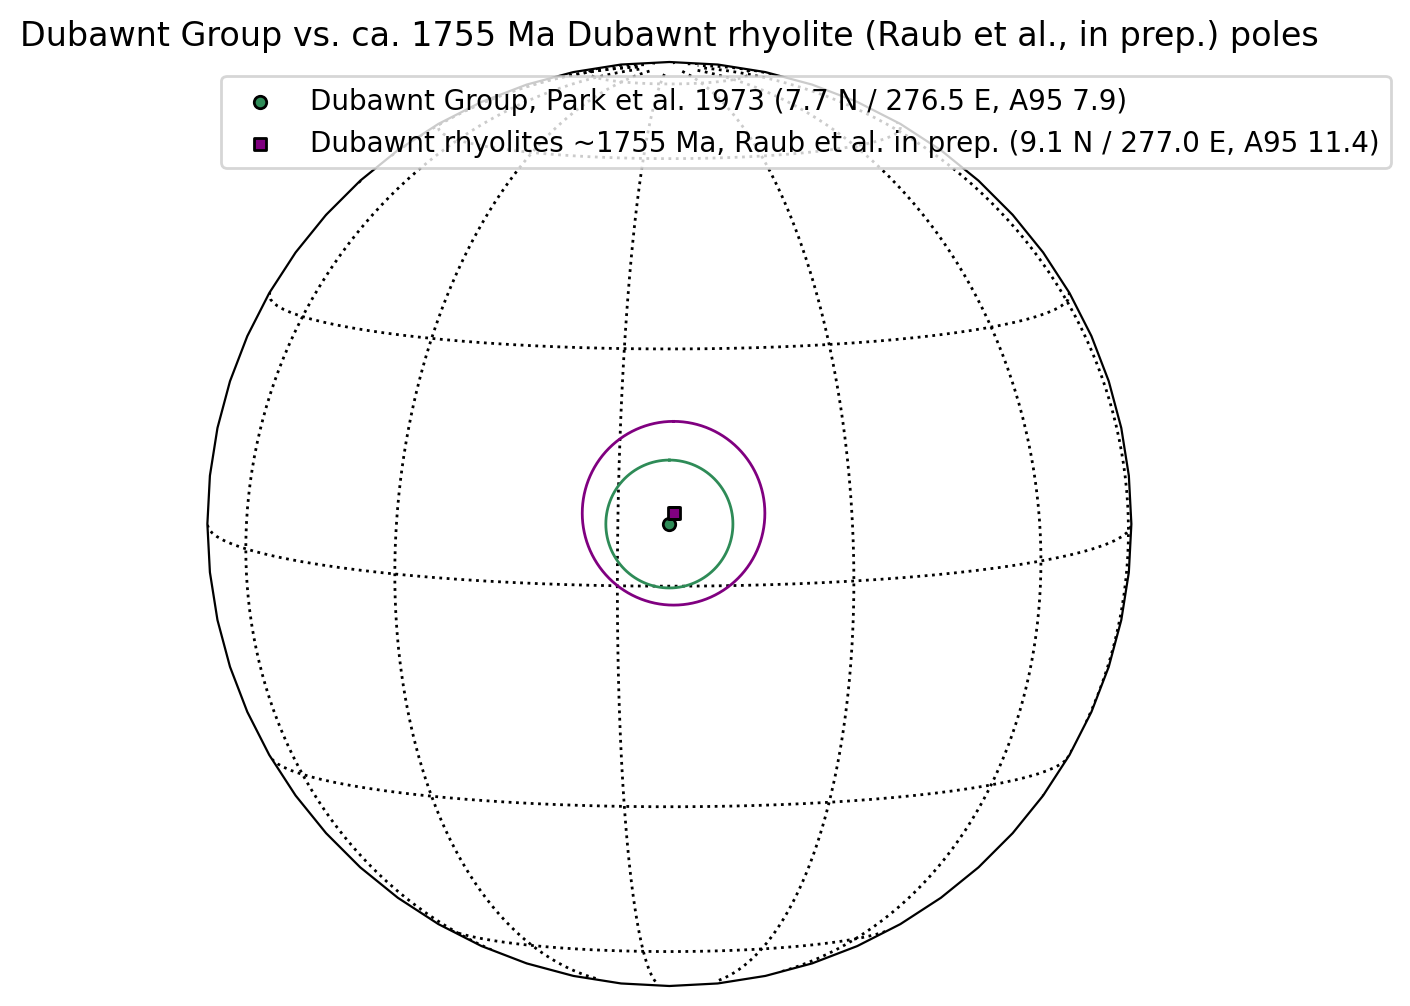

In [9]:
# Companion pole: Dubawnt rhyolites at ca. 1755 Ma, Raub et al. (in prep., CJES same volume).
raub_plat, raub_plon, raub_A95 = 9.1, 277.0, 11.4
raub_age = 1755

ax = ipmag.make_orthographic_map(central_longitude=pole_mean['dec'], central_latitude=pole_mean['inc'],
                                 figsize=(6, 6), add_land=False, add_ocean=False)
ipmag.plot_pole(ax, pole_mean['dec'], pole_mean['inc'], pole_mean['alpha95'], color='seagreen',
                marker='o', legend='yes',
                label=f"Dubawnt Group, Park et al. 1973 "
                      f"({pole_mean['inc']:.1f} N / {pole_mean['dec']:.1f} E, A95 {pole_mean['alpha95']:.1f})")
ipmag.plot_pole(ax, raub_plon, raub_plat, raub_A95, color='purple', marker='s', legend='yes',
                label=f'Dubawnt rhyolites ~{raub_age} Ma, Raub et al. in prep. '
                      f'({raub_plat} N / {raub_plon} E, A95 {raub_A95})')
plt.title('Dubawnt Group vs. ca. 1755 Ma Dubawnt rhyolite (Raub et al., in prep.) poles')
plt.show()

## Comparison with the previous compilation pole

The Dubawnt Group pole was previously compiled from Park et al. (1973) as GPMDB
2737. The recalculation above, from the Fisher mean of the 30 site VGPs,
reproduces that compilation pole; the recalculated value is exactly reproducible
from the archived MagIC site data.

In [10]:
compilation_plat, compilation_plon, compilation_A95 = 7.0, 277.0, 8.0
separation = float(pmag.angle([pole_mean['dec'], pole_mean['inc']],
                              [compilation_plon, compilation_plat])[0])
print(f"this study (N={int(pole_mean['n'])}):        "
      f"{pole_mean['inc']:.1f} N, {pole_mean['dec']:.1f} E, A95 {pole_mean['alpha95']:.1f}")
print(f"previous compilation (GPMDB 2737): "
      f"{compilation_plat:.1f} N, {compilation_plon:.1f} E, A95 {compilation_A95:.1f}")
print(f"separation: {separation:.1f} deg (well within the mutual A95)")

this study (N=30):        7.7 N, 276.5 E, A95 7.9
previous compilation (GPMDB 2737): 7.0 N, 277.0 E, A95 8.0
separation: 0.9 deg (well within the mutual A95)


## R2: Techniques and statistical analysis (Meert et al., 2020)

Park et al. (1973) used stepwise thermal and alternating-field demagnetization
with stable-endpoint (blanket) cleaning; principal-component analysis was not
available, and per-site alpha95/k were not reported. The VGP-scatter diagnostics
below evaluate whether paleosecular variation is adequately sampled.

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: yes
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: no
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 127 samples (>= 25): PASS
        K = 12.0 (10-70): PASS
        B = 30 sites (>= 8): PASS
        min 1 samples/site [advisory only, not a gate; Sapienza et al., 2023]
        A95 = 7.9 in Deenen envelope [3.1, 9.6]: PASS
  => R2 (from sub-criterion c) = 1

A_95 of 7.9 passes Deenen et al. (2011) criteria of being between 3.1 and 9.6 for this number of sites


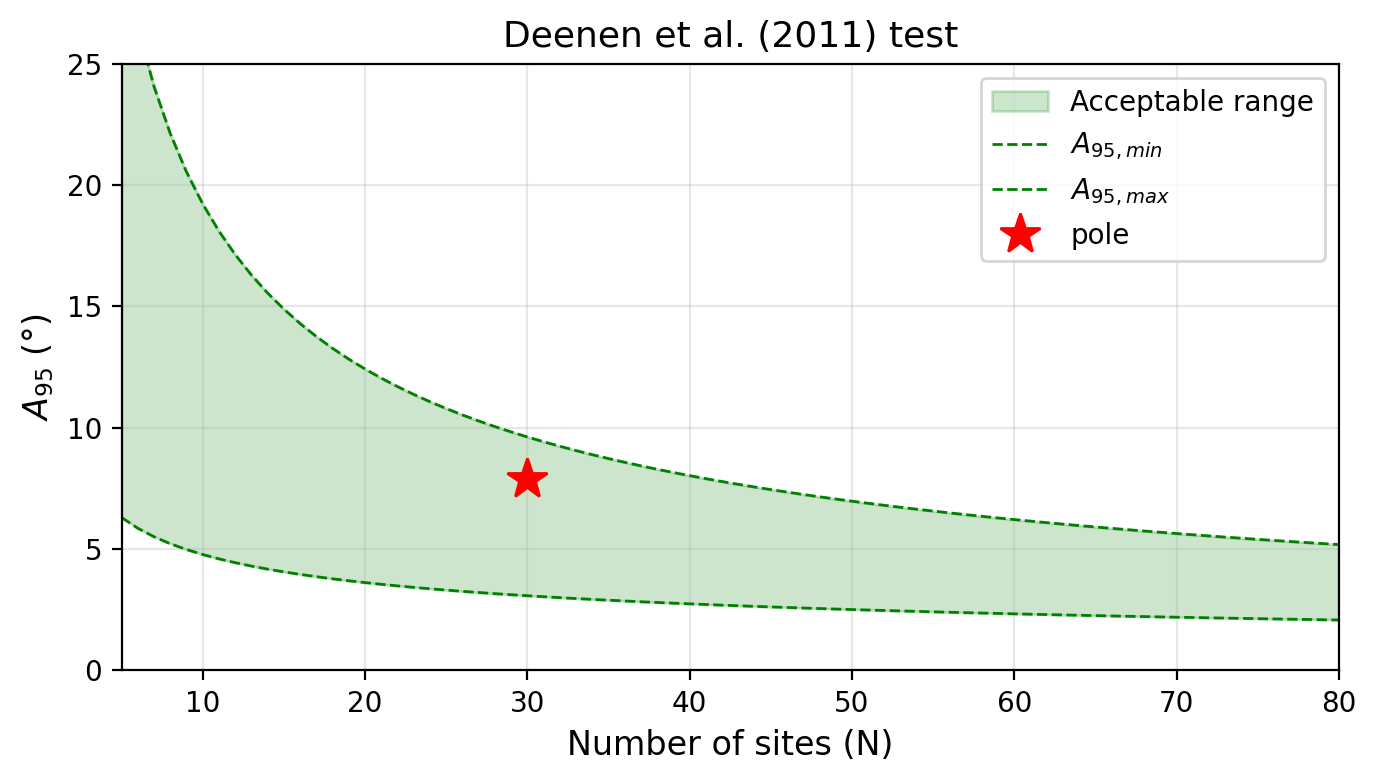

In [11]:
r2 = pt.assess_R2(sites_pole, pole_mean)
print()
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()

### Supplementary: VGP distribution-shape diagnostics (Fisher Q-Q and SVEI)

{'Mode': 'Mode 1',
 'Dec': np.float64(276.62958242507693),
 'Inc': np.float64(7.126337499822405),
 'N': 30,
 'Mu': np.float64(1.0912287017101123),
 'Mu_critical': 1.207,
 'Me': np.float64(0.9189552913833408),
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

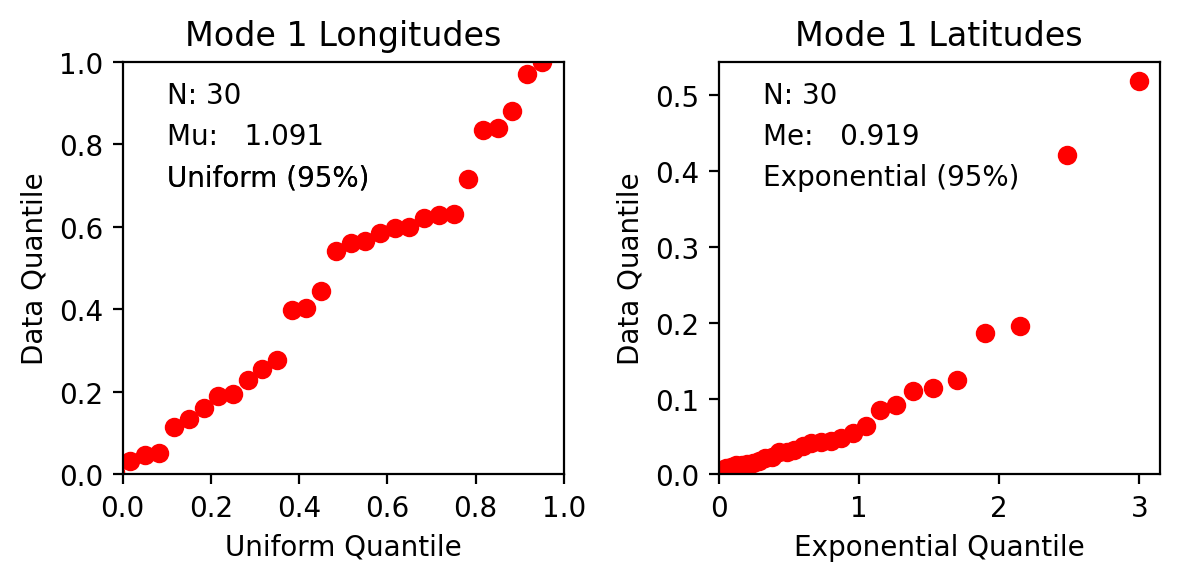

In [12]:
fishqq_result = pt.fishqq_vgps(sites_pole, unify_polarity=True)
fishqq_result

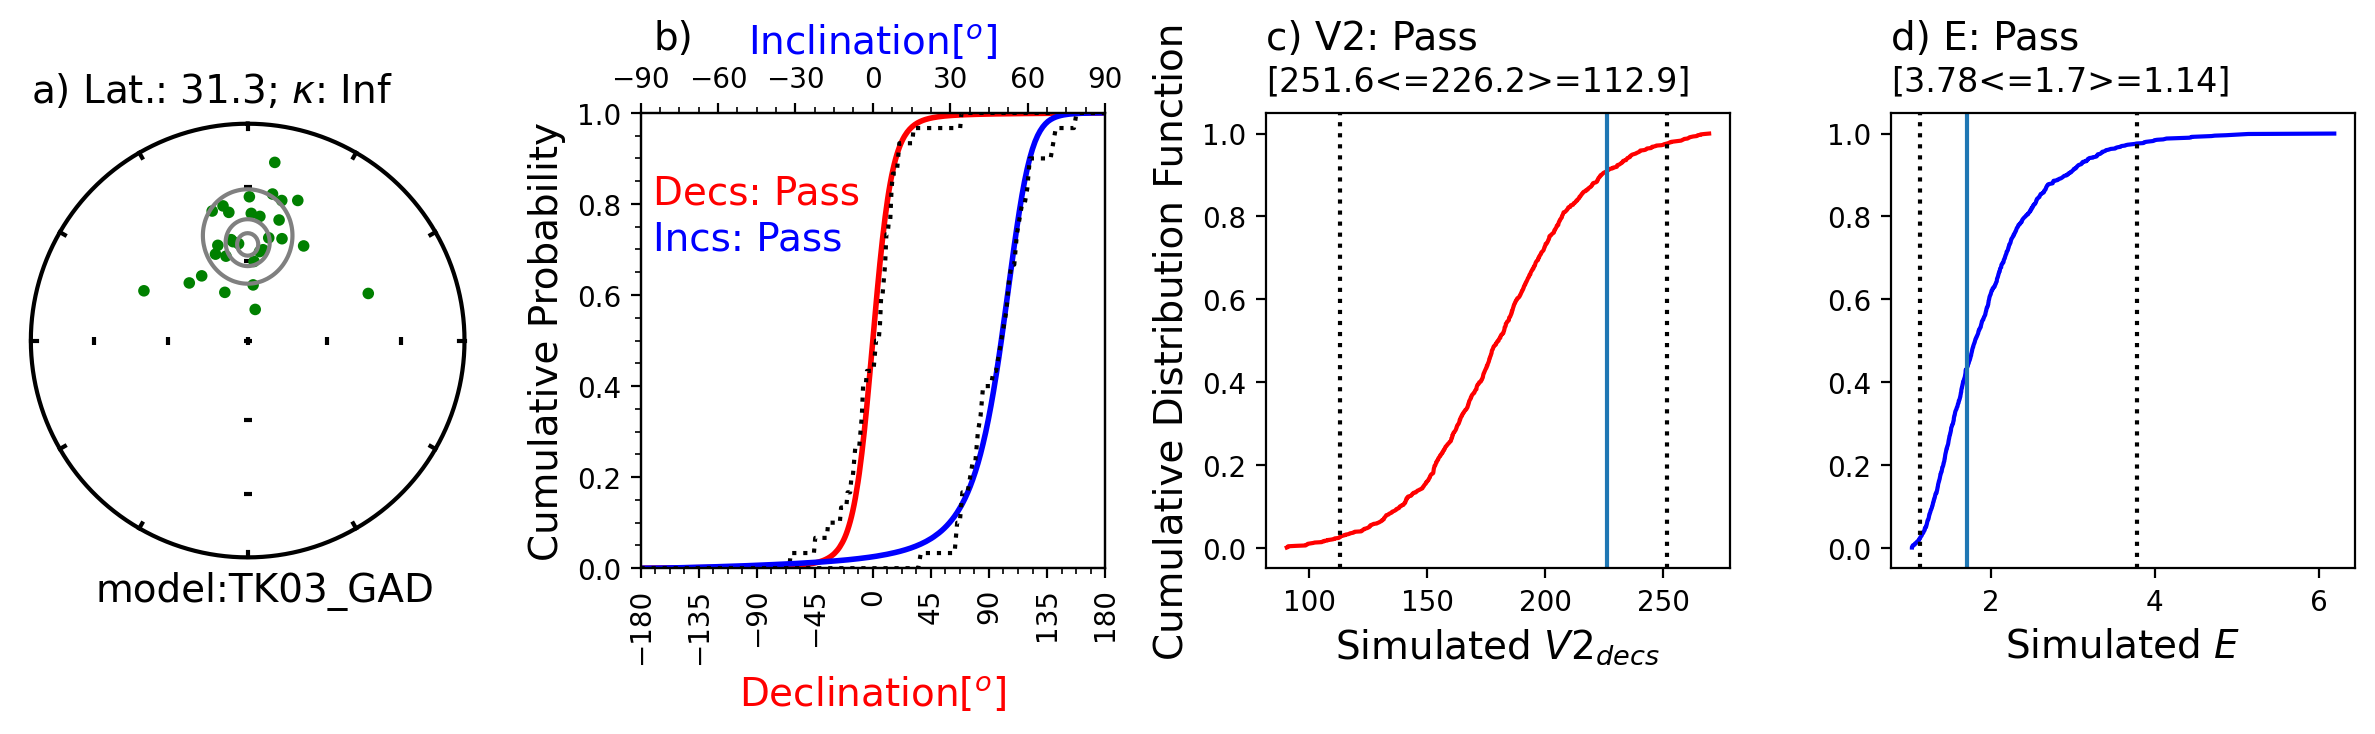

paleolatitude = 31.3 deg; elongation E = 1.70 (consistent with TK03.GAD)


In [13]:
try:
    svei_result = pt.svei_test_vgps(sites_pole, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(sites_pole, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## R7: Comparison with younger Laurentia poles

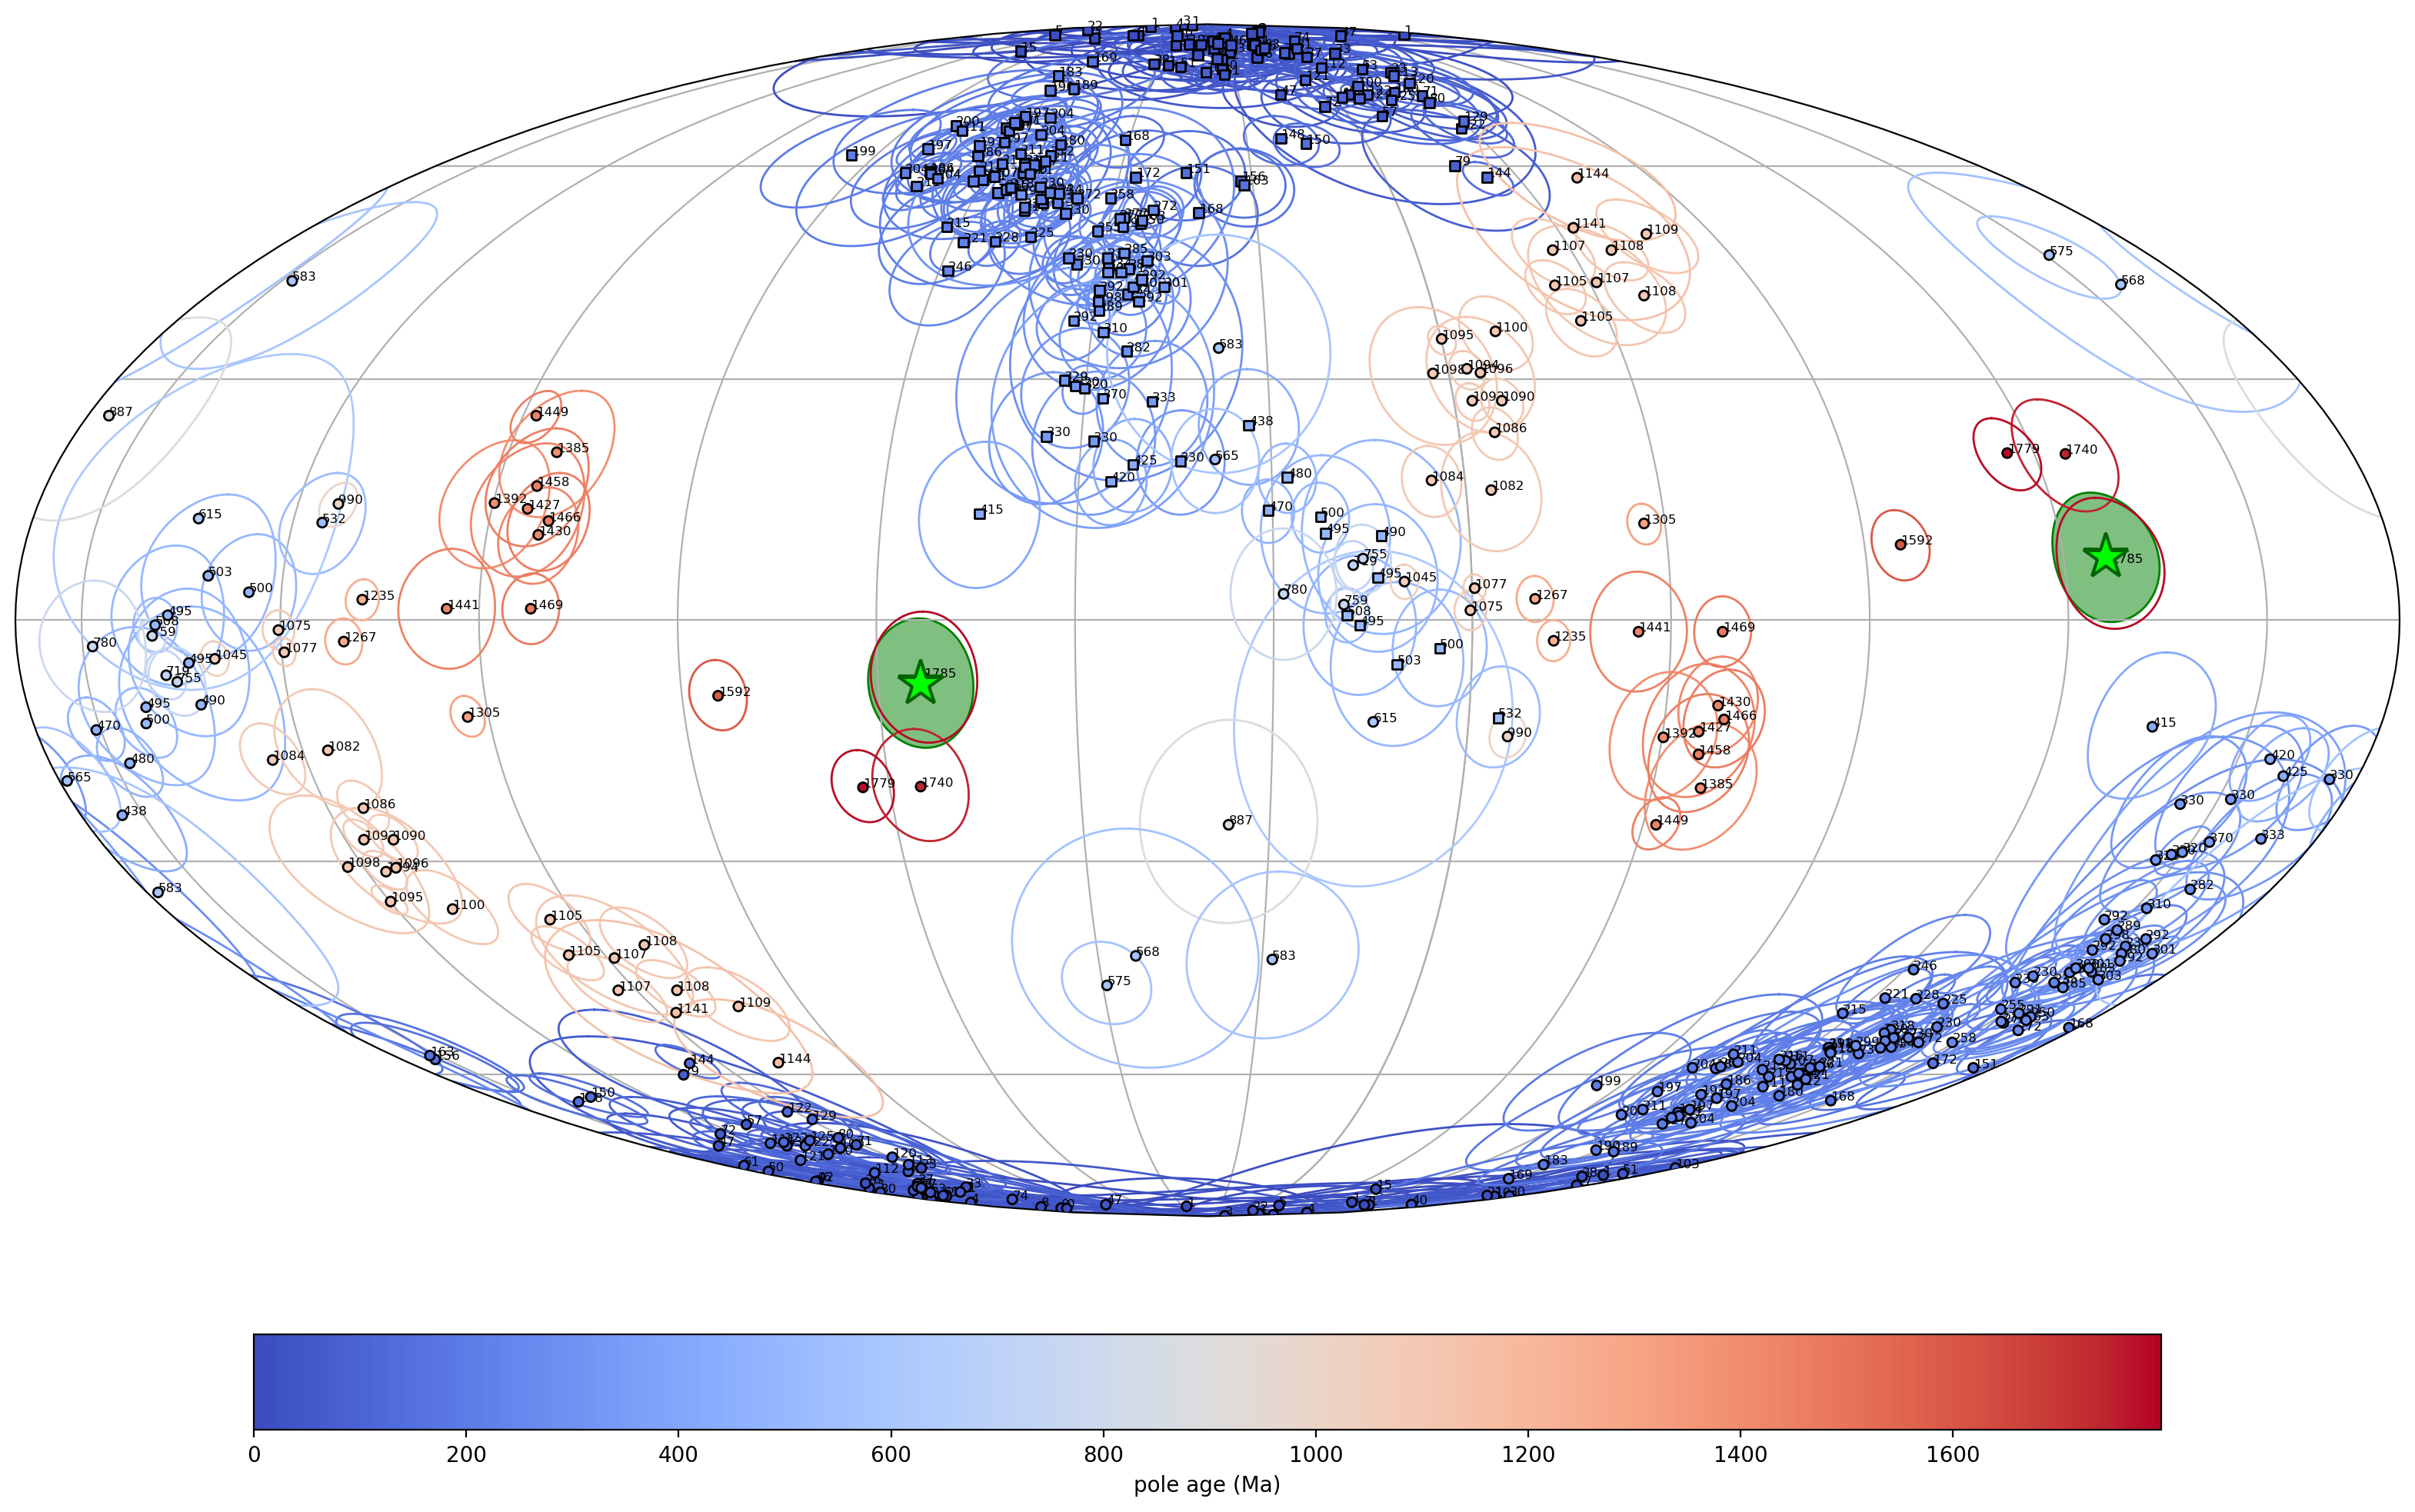

<GeoAxes: >

In [14]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Dubawnt Group', Laurentia_stricto_poles, pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1796)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within +/- 15 Ma | **0** | The pole age is a bracket, 1758-1833 Ma (nominal 1796 Ma); the sampled units are not directly dated, so the +/- 37 Ma half-width exceeds +/- 15 Ma. |
| 2 | Techniques and statistical analysis | **0** | Thermal and alternating-field demagnetization with stable-endpoint cleaning; no principal-component analysis, and per-site alpha95/k were not reported (Park et al., 1973). |
| 3 | Magnetic mineralogy characterized | **1** | Hematite (red beds) and specular hematite + magnetite / titanomagnetite (volcanics, dikes) identified by reflected-light petrography and IRM-coercivity spectra. |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test: dikes at sites 2 and 9 bake the Hudsonian basement and Kazan sandstone, which carry the dike direction (MagIC ST-C). |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous western Churchill Province; the succession is faulted but essentially unfolded (the fold test is only marginally positive), and bedding corrections are small. |
| 6 | Presence of reversals | **1** | Dual polarity with normal and reversed means 4 deg apart, indistinguishable within error (a positive reversal test). |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles. |
| | **Total** | **5/7** | Grade B |

## Nordic workshop ranking

The Dubawnt Group pole (GPMDB 2737) retains its Grade B ranking. The Nordic
summary below reports the recalculated pole and direction, computed as the Fisher
mean of the 30 bedding-corrected site VGPs of Park et al. (1973), with the age
updated to 1796 Ma (bracket 1758-1833) from the geochronology of Rainbird et al.
(2006) and Rainbird & Davis (2007).

In [15]:
Dubawnt_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Dubawnt Group',
    sites=sites_pole,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Characteristic remanent magnetization carried by hematite (red beds) and specular hematite plus magnetite (volcanics and dikes)',
    tests='C+ (positive baked-contact test: dikes at sites 2 and 9 bake Hudsonian basement and Kazan sandstone, which carry the dike direction = MagIC ST-C) and R+ (positive reversal test: normal and reversed means 4 deg apart, indistinguishable within error)',
    gpmdb_number='2737',
    percent_reversed=67,
    demag_code=3,
    R1=0, R2=0, R3=1, R4='C', R5=1, R6=1, R7=1,
    Grade='B', Grade_E21='B',
    nominal_age=1796, lomagage=1758, himagage=1833,
    REF_method="Nominal age 1796 Ma; bracket 1758-1833 Ma. Park et al. (1973) sampled the Kazan Formation, Christopher Island Formation and Martell Syenite of the Baker Lake Group. Rainbird et al. (2006) date a basal Christopher Island felsic minette flow at 1833 +/- 3 Ma (U-Pb zircon) and a syenite plug that cross-cuts the sampled Kazan and Christopher Island Formations at 1811 +/- 12 Ma (Ar-Ar phlogopite, a minimum age for the sampled units). Rainbird & Davis (2007) date Pitz Formation rhyolite of the overlying Wharton Group at 1757.6 +/- 3.4 Ma. The conservative 1758-1833 Ma bracket spans these U-Pb dates; the cross-cutting 1811 Ma syenite indicates the pole most likely lies in the older half. Park et al.'s original K-Ar (~1716 Ma) and Rb-Sr (1725 +/- 4 Ma) ages used old decay constants and are superseded.",
    POLE_AUTHORS='Park, J. K., Irving, E., & Donaldson, J. A.',
    YEAR=1973,
    JOURNAL='Geological Society of America Bulletin',
    VOLUME=84,
    VPAGES='859-870',
    TITLE='Paleomagnetism of the Precambrian Dubawnt Group',
    COMMENT='Pole recalculated as the Fisher mean of the 30 bedding-corrected site VGPs of Park et al. (1973) Table 1 (VGPs computed from the cleaned directions at the mean sampling location); reproduces the published pole (7 N / 277 E) within rounding. A bootstrap common-mean test shows the sedimentary (red bed) and volcanic site directions share a common mean, justifying the combined pole. Age updated to 1796 Ma (bracket 1758-1833) from Rainbird et al. (2006) and Rainbird & Davis (2007). Documented in Swanson-Hysell et al. (2026).'
)
Dubawnt_summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia,Dubawnt Group,2737,,Characteristic remanent magnetization carried ...,C+ (positive baked-contact test: dikes at site...,100,64.1,265.3,30,...,Nominal age 1796 Ma; bracket 1758-1833 Ma. Par...,Dubawnt Group,"Park, J. K., Irving, E., & Donaldson, J. A.",1973,Geological Society of America Bulletin,84,859-870,Paleomagnetism of the Precambrian Dubawnt Group,Pole recalculated as the Fisher mean of the 30...,Syenite; Trachyte; Sandstone; Basalt; Mudstone


In [16]:
# save the summary as a single-row CSV in data/nordic_summaries
pt.save_nordic_summary(Dubawnt_summary, '1796_Dubawnt')

'../data/nordic_summaries/1796_Dubawnt.csv'